# Cài đặt

In [ ]:
# =============================
# Bước 0: Cài đặt và tải dữ liệu
# =============================
!pip install torch torchtext spacy nltk
!python -m spacy download en_core_web_sm
!python -m spacy download fr_core_news_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 100.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 82.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# Thư Viện

In [ ]:
import os
import random
import time
from collections import Counter

import spacy
import nltk

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from nltk.translate.bleu_score import corpus_bleu

import matplotlib.pyplot as plt

In [ ]:
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)

Device: cuda


# load data

In [ ]:
def read_lines(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f]

train_en = read_lines(os.path.join("/content/drive/MyDrive/English_French_Machine_Translation_With_Encoder_Decoder_LSTM_Model/data/train.en"))
train_fr = read_lines(os.path.join("/content/drive/MyDrive/English_French_Machine_Translation_With_Encoder_Decoder_LSTM_Model/data/train.fr"))
val_en   = read_lines(os.path.join("/content/drive/MyDrive/English_French_Machine_Translation_With_Encoder_Decoder_LSTM_Model/data/val.en"))
val_fr   = read_lines(os.path.join("/content/drive/MyDrive/English_French_Machine_Translation_With_Encoder_Decoder_LSTM_Model/data/val.fr"))
test_fr  = read_lines(os.path.join("/content/drive/MyDrive/English_French_Machine_Translation_With_Encoder_Decoder_LSTM_Model/data/test.fr"))
test_en  = read_lines(os.path.join("/content/drive/MyDrive/English_French_Machine_Translation_With_Encoder_Decoder_LSTM_Model/data/test.en"))

In [ ]:
print("Counts:", len(train_en), len(val_en), len(test_en))
print("Counts:", len(train_fr), len(val_fr), len(test_fr))

Counts: 29000 1014 1071
Counts: 29000 1014 1071


# 2. Tokenizers (spaCy)

In [ ]:
nlp_en = spacy.load("en_core_web_sm")
nlp_fr = spacy.load("fr_core_news_sm")

def tokenize_en(text):
    return [tok.text.lower() for tok in nlp_en.tokenizer(text)]

def tokenize_fr(text):
    return [tok.text.lower() for tok in nlp_fr.tokenizer(text)]

# 3. Build vocabularies (limit top_k)

In [ ]:
TOP_K = 10000
MIN_FREQ = 1
SPECIALS = ["<pad>", "<sos>", "<eos>", "<unk>"]

def build_vocab_from_tokenized(sentences_tok, top_k=TOP_K, min_freq=MIN_FREQ):
    counter = Counter()
    for tokens in sentences_tok:
        counter.update(tokens)
    most = [w for w,c in counter.most_common(top_k) if c >= min_freq]
    stoi = {tok: idx for idx, tok in enumerate(SPECIALS)}
    for w in most:
        if w not in stoi:
            stoi[w] = len(stoi)
    itos = {idx: tok for tok, idx in stoi.items()}
    return stoi, itos

In [ ]:
TOP_K = 10000                                      # Lấy tối đa 10,000 từ xuất hiện nhiều nhất
MIN_FREQ = 1                                       # Những từ xuất hiện ít hơn 1 lần thì bỏ (tức là giữ tất cả)
SPECIALS = ["<pad>", "<sos>", "<eos>", "<unk>"]    # Các token đặc biệt

def build_vocab_from_tokenized(sentences_tok, top_k=TOP_K, min_freq=MIN_FREQ):
    """
    Hàm xây dựng từ điển (vocabulary) từ dữ liệu đã được tokenize

    Tham số:
    - sentences_tok: danh sách các câu đã tokenize (list of list tokens)
    - top_k: số lượng từ tối đa giữ lại trong vocab
    - min_freq: tần suất xuất hiện tối thiểu của từ

    Trả về:
    - stoi: dict ánh xạ từ -> chỉ số (string to index)
    - itos: dict ánh xạ chỉ số -> từ (index to string)
    """

    counter = Counter()
    # Counter giúp đếm tần suất xuất hiện của toàn bộ từ

    for tokens in sentences_tok:
        counter.update(tokens)
        # Cập nhật tần suất cho từng token

    # Lấy ra danh sách các từ phổ biến theo tần suất,
    # chỉ giữ top_k từ, và tần suất ≥ min_freq
    most = [w for w, c in counter.most_common(top_k) if c >= min_freq]

    # Tạo dictionary stoi: string → index với các token đặc biệt đứng đầu
    stoi = {tok: idx for idx, tok in enumerate(SPECIALS)}

    # Gán index cho các từ trong vocab
    for w in most:
        if w not in stoi:
            stoi[w] = len(stoi)
            # Từ mới sẽ lấy index kế tiếp

    # Tạo dictionary ngược itos: index → string
    itos = {idx: tok for tok, idx in stoi.items()}

    return stoi, itos


In [ ]:
train_en_tok = [tokenize_en(s) for s in train_en]
train_fr_tok = [tokenize_fr(s) for s in train_fr]

stoi_en, itos_en = build_vocab_from_tokenized(train_en_tok)
stoi_fr, itos_fr = build_vocab_from_tokenized(train_fr_tok)

PAD_IDX = stoi_fr["<pad>"]
SOS_IDX = stoi_fr["<sos>"]
EOS_IDX = stoi_fr["<eos>"]
UNK_IDX = stoi_fr["<unk>"]

# 4. Dataset + collate_fn

In [ ]:
def numericalize(tokens, stoi, add_sos_eos=False):
  if add_sos_eos:
    seq = [stoi["<sos>"]] + [stoi.get(t, stoi["<unk>"]) for t in tokens] + [stoi["<eos>"]]
  else:
    seq = [stoi.get(t, stoi["<unk>"]) for t in tokens]
  return seq

In [ ]:
class TranslationDataset(Dataset):
    """
    Dataset cho bài toán dịch máy (Machine Translation).
    Mỗi phần tử gồm:
    - Câu nguồn (src) đã tokenize
    - Câu đích (trg) đã tokenize
    """

    def __init__(self, src_list, trg_list, src_tokenizer, trg_tokenizer, src_stoi, trg_stoi):
        # Đảm bảo số câu nguồn và câu đích bằng nhau
        assert len(src_list) == len(trg_list)

        # Danh sách câu nguồn (ví dụ: tiếng Anh)
        self.src = src_list

        # Danh sách câu đích (ví dụ: tiếng Pháp)
        self.trg = trg_list

        # Hàm tokenize cho câu nguồn
        self.src_tokenizer = src_tokenizer

        # Hàm tokenize cho câu đích
        self.trg_tokenizer = trg_tokenizer

        # Từ điển word → index cho câu nguồn
        self.src_stoi = src_stoi

        # Từ điển word → index cho câu đích
        self.trg_stoi = trg_stoi

    def __len__(self):
        """
        Trả về số lượng cặp câu trong dataset
        """
        return len(self.src)

    def __getitem__(self, idx):
        """
        Lấy một mẫu dữ liệu tại vị trí idx
        """

        # Tokenize câu nguồn tại vị trí idx
        src_tokens = self.src_tokenizer(self.src[idx])

        # Tokenize câu đích tại vị trí idx
        trg_tokens = self.trg_tokenizer(self.trg[idx])

        # Trả về cặp (src_tokens, trg_tokens)
        # Việc chuyển sang index, padding sẽ làm ở collate_fn
        return src_tokens, trg_tokens

In [ ]:
def collate_fn(batch):
  """
    Hàm gom (collate) một batch dữ liệu cho DataLoader.
    - Chuyển token → index
    - Thêm <sos>, <eos> cho câu đích
    - Sắp xếp theo độ dài giảm dần (phục vụ pack_padded_sequence)
    - Padding các câu về cùng độ dài
    """

  src_batch, trg_batch = [], []

  # 1. Duyệt từng cặp (src_tokens, trg_tokens) trong batch
  for src_tokens, trg_tokens in batch:
      src_batch.append(numericalize(src_tokens, stoi_en, add_sos_eos=False))
      trg_batch.append(numericalize(trg_tokens, stoi_fr, add_sos_eos=True))

  # 2. Lấy độ dài từng câu (trước khi padding)
  src_lengths = [len(s) for s in src_batch]
  trg_lengths = [len(t) for t in trg_batch]

  # 3. Sắp xếp batch theo độ dài câu nguồn giảm dần
  sorted_idx = sorted(range(len(src_lengths)), key=lambda i: src_lengths[i], reverse=True)

  # Áp dụng thứ tự đã sắp xếp
  src_batch = [torch.tensor(src_batch[i], dtype=torch.long) for i in sorted_idx]
  trg_batch = [torch.tensor(trg_batch[i], dtype=torch.long) for i in sorted_idx]
  src_lengths = [src_lengths[i] for i in sorted_idx]
  trg_lengths = [trg_lengths[i] for i in sorted_idx]

  # 4. Padding các câu về cùng độ dài trong batch
  src_padded = pad_sequence(src_batch, batch_first=True, padding_value=stoi_en["<pad>"])
  trg_padded = pad_sequence(trg_batch, batch_first=True, padding_value=stoi_fr["<pad>"])

  return (src_padded.to(DEVICE),
          torch.tensor(src_lengths, dtype=torch.long).to(DEVICE),
          trg_padded.to(DEVICE),
          torch.tensor(trg_lengths, dtype=torch.long).to(DEVICE))


In [ ]:
train_ds = TranslationDataset(train_en, train_fr, tokenize_en, tokenize_fr, stoi_en, stoi_fr)
val_ds   = TranslationDataset(val_en,   val_fr,   tokenize_en, tokenize_fr, stoi_en, stoi_fr)
test_ds  = TranslationDataset(test_en,  test_fr,  tokenize_en, tokenize_fr, stoi_en, stoi_fr)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)

#5. Model: Attention, Encoder, Decoder, Seq2Seq

In [ ]:
# ---------------------------
# Model: Luong Attention + Encoder/Decoder
# ---------------------------
class LuongAttention(nn.Module):

    """
    Luong Attention:
    - Tính trọng số chú ý (attention weights) giữa hidden state của Decoder và toàn bộ hidden states của Encoder.
    - Giúp Decoder tập trung vào các từ quan trọng trong câu nguồn khi sinh ra từng từ đích.
    """

    def __init__(self, hid_dim):
        super().__init__()
        self.attn = nn.Linear(hid_dim, hid_dim, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, mask):
        # decoder_hidden: [batch, hid]
        # encoder_outputs: [batch, src_len, hid]
        dec_hidden = self.attn(decoder_hidden).unsqueeze(2)
        energy = torch.bmm(encoder_outputs, dec_hidden).squeeze(2)
        energy = energy.masked_fill(mask == 0, -1e10)
        attn_weights = torch.softmax(energy, dim=1)
        return attn_weights  # [batch, src_len]

class Encoder(nn.Module):

    """
    Encoder:
    - Nhận câu nguồn (tiếng Anh) dưới dạng chuỗi chỉ số từ.
    - Sử dụng Embedding + LSTM nhiều tầng để mã hoá câu nguồn
      thành chuỗi vector ngữ nghĩa (encoder_outputs).
    - Trả về:
        + encoder_outputs: biểu diễn ngữ cảnh của từng từ nguồn
        + hidden, cell: trạng thái cuối của LSTM, dùng để khởi tạo Decoder
    """


    def __init__(self, input_dim, emb_dim, hid_dim, n_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=stoi_en["<pad>"])
        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lengths):
        embedded = self.dropout(self.embedding(src))
        packed = pack_padded_sequence(embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=True)
        packed_outputs, (hidden, cell) = self.rnn(packed)
        outputs, _ = pad_packed_sequence(packed_outputs, batch_first=True)
        return outputs, hidden, cell

class Decoder(nn.Module):

    """
    Decoder:
    - Sinh từng từ của câu đích (tiếng Pháp) theo từng bước thời gian.
    - Ở mỗi bước:
        + Nhận từ trước đó
        + Áp dụng Luong Attention để lấy context từ Encoder
        + Kết hợp embedding + context đưa vào LSTM
        + Dự đoán từ tiếp theo
    """

    def __init__(self, output_dim, emb_dim, hid_dim, n_layers=2, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.LSTM(emb_dim + hid_dim, hid_dim, n_layers, dropout=dropout, batch_first=True)
        self.fc_out = nn.Linear(hid_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)
        self.attention = LuongAttention(hid_dim)

    def forward(self, input_step, hidden, cell, encoder_outputs, mask):
        input_step = input_step.unsqueeze(1)
        embedded = self.dropout(self.embedding(input_step))

        dec_hidden = hidden[-1]
        attn_weights = self.attention(dec_hidden, encoder_outputs, mask)
        attn_weights_unsq = attn_weights.unsqueeze(1)

        context = torch.bmm(attn_weights_unsq, encoder_outputs)
        rnn_input = torch.cat((embedded, context), dim=2)

        output, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))
        output = output.squeeze(1)
        context = context.squeeze(1)

        pred = self.fc_out(torch.cat((output, context), dim=1))
        return pred, hidden, cell, attn_weights

class Seq2Seq(nn.Module):

    """
    Seq2Seq:
    - Kết hợp Encoder và Decoder thành mô hình dịch hoàn chỉnh.
    - Trong quá trình huấn luyện:
        + Encoder mã hoá câu nguồn
        + Decoder sinh câu đích với teacher forcing
    - Được dùng cho cả train và validation
    """

    def __init__(self, encoder, decoder, device, trg_pad_idx=PAD_IDX):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device
        self.trg_pad_idx = trg_pad_idx

    def create_mask(self, src):
        return (src != stoi_en["<pad>"]).to(self.device)  # [batch, src_len]

    def forward(self, src, src_lengths, trg, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = trg.size(1)
        trg_vocab_size = self.decoder.fc_out.out_features
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)

        encoder_outputs, hidden, cell = self.encoder(src, src_lengths)
        mask = self.create_mask(src)

        input_token = trg[:, 0]  # <sos>
        for t in range(1, trg_len):
            output, hidden, cell, _ = self.decoder(input_token, hidden, cell, encoder_outputs, mask)
            outputs[:, t, :] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input_token = trg[:, t] if teacher_force else top1

        return outputs

In [ ]:
# ---------------------------
# Init model / optimizer / loss
# ---------------------------
INPUT_DIM = len(stoi_en)
OUTPUT_DIM = len(stoi_fr)
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 2
DROPOUT = 0.3

enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, n_layers=N_LAYERS, dropout=DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, n_layers=N_LAYERS, dropout=DROPOUT)
model = Seq2Seq(enc, dec, DEVICE, trg_pad_idx=PAD_IDX).to(DEVICE)

In [ ]:
# parameter count
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)
print("Params:", count_params(model))

Params: 23990292


# 6. Training setup

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def epoch_time(start_time, end_time):
    elapsed = end_time - start_time
    m = int(elapsed/60)
    s = int(elapsed - m*60)
    return m, s


# 7. Train loop with early stopping

In [ ]:
N_EPOCHS = 20
CLIP = 1.0
patience = 3

best_valid_loss = float('inf')
stale = 0
train_losses, valid_losses = [], []

for epoch in range(N_EPOCHS):
    start_time = time.time()
    model.train()
    train_loss = 0

    for src, src_lens, trg, trg_lens in train_loader:
        src, src_lens, trg = src.to(DEVICE), src_lens.to(DEVICE), trg.to(DEVICE)
        optimizer.zero_grad()
        output = model(src, src_lens, trg, teacher_forcing_ratio=0.5)
        output_dim = output.shape[-1]
        output = output[:,1:,:].reshape(-1, output_dim)
        trg_y = trg[:,1:].reshape(-1)
        loss = criterion(output, trg_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    valid_loss = 0
    with torch.no_grad():
        for src, src_lens, trg, trg_lens in val_loader:
            src, src_lens, trg = src.to(DEVICE), src_lens.to(DEVICE), trg.to(DEVICE)
            output = model(src, src_lens, trg, teacher_forcing_ratio=0.0)
            output_dim = output.shape[-1]
            output = output[:,1:,:].reshape(-1, output_dim)
            trg_y = trg[:,1:].reshape(-1)
            loss = criterion(output, trg_y)
            valid_loss += loss.item()

    train_loss = train_loss / len(train_loader)
    valid_loss = valid_loss / len(val_loader)
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    end_time = time.time()
    epoch_m, epoch_s = epoch_time(start_time, end_time)
    print(f"Epoch {epoch+1} | Time {epoch_m}m {epoch_s}s | Train Loss: {train_loss:.4f} | Val Loss: {valid_loss:.4f}")

    # early stopping & save best
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_model_state = model.state_dict()
        stale = 0
    else:
        stale += 1
        if stale >= patience:
            print("Early stopping triggered.")
            break

Epoch 1 | Time 1m 35s | Train Loss: 4.5686 | Val Loss: 4.2521
Epoch 2 | Time 1m 34s | Train Loss: 3.4034 | Val Loss: 3.7407
Epoch 3 | Time 1m 35s | Train Loss: 2.8495 | Val Loss: 3.4610
Epoch 4 | Time 1m 35s | Train Loss: 2.4810 | Val Loss: 3.3573
Epoch 5 | Time 1m 35s | Train Loss: 2.2139 | Val Loss: 3.1909
Epoch 6 | Time 1m 35s | Train Loss: 2.0163 | Val Loss: 3.2353
Epoch 7 | Time 1m 35s | Train Loss: 1.8295 | Val Loss: 3.1741
Epoch 8 | Time 1m 35s | Train Loss: 1.6986 | Val Loss: 3.1407
Epoch 9 | Time 1m 35s | Train Loss: 1.5651 | Val Loss: 3.1681
Epoch 10 | Time 1m 35s | Train Loss: 1.4783 | Val Loss: 3.1219
Epoch 11 | Time 1m 34s | Train Loss: 1.3799 | Val Loss: 3.1187
Epoch 12 | Time 1m 34s | Train Loss: 1.3436 | Val Loss: 3.1415
Epoch 13 | Time 1m 34s | Train Loss: 1.2748 | Val Loss: 3.1560
Epoch 14 | Time 1m 34s | Train Loss: 1.1901 | Val Loss: 3.2270
Early stopping triggered.


## Save model

In [ ]:
save_dir = "/content/drive/MyDrive/English_French_Machine_Translation_With_Encoder_Decoder_LSTM_Model/best_model"
os.makedirs(save_dir, exist_ok=True)
print(save_dir)


/content/drive/MyDrive/English_French_Machine_Translation_With_Encoder_Decoder_LSTM_Model/best_model


In [ ]:
save_path = os.path.join(save_dir, "best_model.pth")
torch.save(best_model_state, save_path)
print("Model saved at:", save_path)

Model saved at: /content/drive/MyDrive/English_French_Machine_Translation_With_Encoder_Decoder_LSTM_Model/best_model/best_model.pth


## Load model

In [ ]:
model.load_state_dict(torch.load(save_path, map_location=DEVICE))
model.to(DEVICE)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(9797, 256, padding_idx=0)
    (rnn): LSTM(256, 512, num_layers=2, batch_first=True, dropout=0.3)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (embedding): Embedding(10004, 256, padding_idx=0)
    (rnn): LSTM(768, 512, num_layers=2, batch_first=True, dropout=0.3)
    (fc_out): Linear(in_features=1024, out_features=10004, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
    (attention): LuongAttention(
      (attn): Linear(in_features=512, out_features=512, bias=False)
    )
  )
)

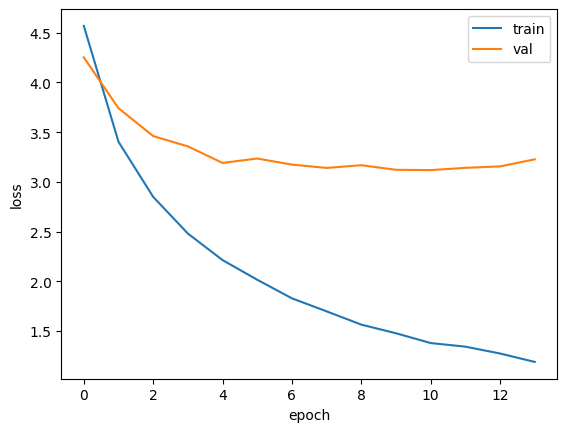

In [ ]:
plt.plot(train_losses, label="train")
plt.plot(valid_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

# 8. Translate function (beam_search)

In [ ]:
def translate_sentence_beam(sentence, model, beam_width=5, max_len=50):
    model.eval()

    # Chuẩn hoá input
    tokens = tokenize_en(sentence)
    src_indices = [stoi_en.get(t, UNK_IDX) for t in tokens]
    src_tensor = torch.tensor(src_indices, dtype=torch.long).unsqueeze(0).to(DEVICE)
    src_len = torch.tensor([len(src_indices)], dtype=torch.long).to(DEVICE)

    # Encoder
    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src_tensor, src_len)
        mask = model.create_mask(src_tensor)

    # Beam: mỗi phần tử = (sequence, hidden, cell, score)
    beams = [( [SOS_IDX], hidden, cell, 0 )]  # log-prob score

    for _ in range(max_len):
        new_beams = []

        for seq, h, c, score in beams:

            last_token = seq[-1]

            # Nếu đã kết thúc câu
            if last_token == EOS_IDX:
                new_beams.append((seq, h, c, score))
                continue

            input_token = torch.tensor([last_token], dtype=torch.long).to(DEVICE)

            with torch.no_grad():
                output, h_new, c_new, _ = model.decoder(
                    input_token, h, c, encoder_outputs, mask
                )

            log_probs = torch.log_softmax(output, dim=1)  # [1, vocab]
            topk_log_probs, topk_ids = torch.topk(log_probs, beam_width)

            # Thêm vào beam mới
            for i in range(beam_width):
                new_seq = seq + [topk_ids[0][i].item()]
                new_score = score + topk_log_probs[0][i].item()
                new_beams.append((new_seq, h_new, c_new, new_score))

        # Giữ lại beam tốt nhất
        new_beams = sorted(new_beams, key=lambda x: x[3], reverse=True)
        beams = new_beams[:beam_width]

        # Nếu toàn bộ beam kết thúc EOS → stop
        if all(b[0][-1] == EOS_IDX for b in beams):
            break

    # Beam tốt nhất
    best_seq = beams[0][0][1:]  # bỏ SOS

    # Dừng ở EOS
    final_words = []
    for idx in best_seq:
        if idx == EOS_IDX:
            break
        final_words.append(itos_fr[idx])

    return " ".join(final_words)


# 9. BLEU trên test(corpus BLEU)

In [ ]:
hyps = []
refs = []

for src_sent, trg_sent in zip(test_en, test_fr):

    # 1. Dự đoán bằng BEAM SEARCH
    hyp = translate_sentence_beam(src_sent, model).split()

    # 2. Tokenize câu French thật (reference)
    ref_tokens = tokenize_fr(trg_sent)

    # 3. Thêm vào list
    hyps.append(hyp)
    refs.append([ref_tokens])  # corpus_bleu yêu cầu dạng [[ref]]

# 4. BLEU
bleu_score = corpus_bleu(refs, hyps)
print(f"BLEU (corpus) on test set: {bleu_score:.4f}")


BLEU (corpus) on test set: 0.2729


In [ ]:
for i in range(20):
    print("EX", i+1)
    print("EN:", test_en[i])
    print("FR_ref:", test_fr[i])
    print("FR_pred:", translate_sentence_beam(test_en[i], model))
    print()


EX 1
EN: A young man participates in a career while the subject who records it smiles.
FR_ref: Un jeune homme participe à une course pendant que le sujet qui le filme sourit.
FR_pred: un jeune homme travaille dans un sauna tandis que le vent qui sourit .

EX 2
EN: The man is scratching the back of his neck while looking for a book in a book store.
FR_ref: L'homme se gratte l'arrière du cou tout en cherchant un livre dans une librairie.
FR_pred: l' homme ajuste le dos de son tandis qu' regardant un livre dans un livre .

EX 3
EN: A person wearing goggles and a hat is sled riding.
FR_ref: Une personne portant des lunettes de protection et un chapeau fait de la luge.
FR_pred: une personne portant des lunettes et des chapeau fait du vélo .

EX 4
EN: A girl in a pink coat and flowered goloshes sledding down a hill.
FR_ref: Une fille avec une veste rose et des galoches à fleurs descend le long d'une colline en luge.
FR_pred: une fille avec un manteau rose et des chaussettes de couleur vive s